<a href="https://colab.research.google.com/github/BimaTriKurniawan/Tugas-Akhir-Statistika-Kelompok-6/blob/main/Kelompok_6_Statistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Library berhasil diimport!

===== INFORMASI DATA =====
Total data Group C : 319
Jumlah sampel      : 100

10 Data Pertama:
0    85
1    63
2    65
3    35
4    70
5    82
6    68
7    32
8    35
9    52
Name: math_score, dtype: int64

     STATISTIKA DESKRIPTIF
Jumlah Data (n) : 100
Rata-rata       : 64.66
Median          : 66.5
Standar Deviasi : 16.048
Variansi        : 257.5398
Nilai Minimum   : 0
Nilai Maksimum  : 98


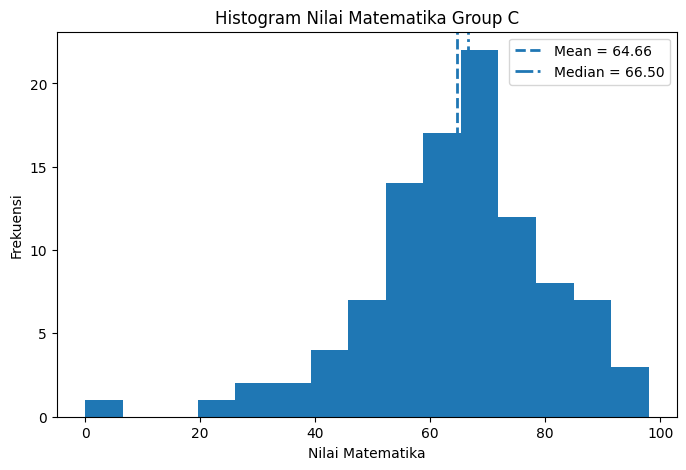

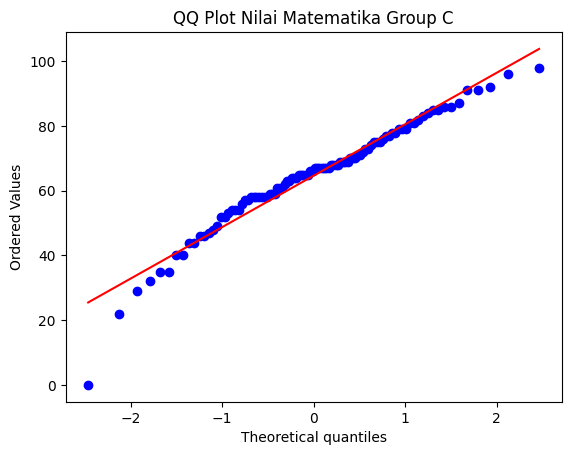


   UJI NORMALITAS KOLMOGOROV-SMIRNOV
D hitung        : 0.0991
D tabel         : 0.136
p-value         : 0.2624
---------------------------------------------
KEPUTUSAN : H0 DITERIMA
Data berdistribusi normal

          ONE SAMPLE T-TEST
Rata-rata sampel : 64.66
Nilai hipotesis  : 65.5
Standar deviasi  : 16.048
Jumlah data      : 100
---------------------------------------------
t hitung         : -0.5234
t tabel          : 1.9842
p-value          : 0.6018
---------------------------------------------
KEPUTUSAN : H0 DITERIMA
Tidak terdapat perbedaan signifikan


In [5]:

# =========================================================
# ANALISIS STATISTIKA
# ONE SAMPLE T-TEST
# DATA NILAI MATEMATIKA SISWA GROUP C
# =========================================================

# ==============================
# IMPORT LIBRARY
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("Library berhasil diimport!")

# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv('study_performance.csv')

# Filter data Group C
groupC = df[df['race_ethnicity'] == 'group C']['math_score']

# Random sampling 100 data
sample = groupC.sample(
    n=100,
    random_state=42
).reset_index(drop=True)

print("\n===== INFORMASI DATA =====")
print("Total data Group C :", len(groupC))
print("Jumlah sampel      :", len(sample))

print("\n10 Data Pertama:")
print(sample.head(10))

# ==============================
# STATISTIK DESKRIPTIF
# ==============================

mean = np.mean(sample)
median = np.median(sample)
std = np.std(sample, ddof=1)
var = np.var(sample, ddof=1)
min_data = np.min(sample)
max_data = np.max(sample)

print("\n========================================")
print("     STATISTIKA DESKRIPTIF")
print("========================================")

print("Jumlah Data (n) :", len(sample))
print("Rata-rata       :", round(mean, 4))
print("Median          :", round(median, 4))
print("Standar Deviasi :", round(std, 4))
print("Variansi        :", round(var, 4))
print("Nilai Minimum   :", min_data)
print("Nilai Maksimum  :", max_data)

print("========================================")

# ==============================
# HISTOGRAM
# ==============================

plt.figure(figsize=(8,5))

plt.hist(
    sample,
    bins=15
)

plt.axvline(
    mean,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean:.2f}'
)

plt.axvline(
    median,
    linestyle='-.',
    linewidth=2,
    label=f'Median = {median:.2f}'
)

plt.title("Histogram Nilai Matematika Group C")
plt.xlabel("Nilai Matematika")
plt.ylabel("Frekuensi")

plt.legend()

plt.show()
plt.close()

# ==============================
# QQ PLOT
# ==============================

stats.probplot(
    sample,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot Nilai Matematika Group C")

plt.show()
plt.close()

# ==============================
# UJI NORMALITAS
# KOLMOGOROV-SMIRNOV
# ==============================

ks_stat, ks_pval = stats.kstest(
    sample,
    'norm',
    args=(mean, std)
)

d_tabel = 1.36 / np.sqrt(len(sample))

print("\n=============================================")
print("   UJI NORMALITAS KOLMOGOROV-SMIRNOV")
print("=============================================")

print("D hitung        :", round(ks_stat, 4))
print("D tabel         :", round(d_tabel, 4))
print("p-value         :", round(ks_pval, 4))

print("---------------------------------------------")

if ks_pval >= 0.05:
    print("KEPUTUSAN : H0 DITERIMA")
    print("Data berdistribusi normal")
else:
    print("KEPUTUSAN : H0 DITOLAK")
    print("Data tidak berdistribusi normal")

print("=============================================")

# ==============================
# ONE SAMPLE T-TEST
# ==============================

# H0 : μ = 65.5
# H1 : μ ≠ 65.5

mu0 = 65.5
alpha = 0.05

t_stat, t_pval = stats.ttest_1samp(
    sample,
    mu0
)

t_tabel = stats.t.ppf(
    1 - alpha/2,
    df=len(sample)-1
)

print("\n=============================================")
print("          ONE SAMPLE T-TEST")
print("=============================================")

print("Rata-rata sampel :", round(mean, 4))
print("Nilai hipotesis  :", mu0)
print("Standar deviasi  :", round(std, 4))
print("Jumlah data      :", len(sample))

print("---------------------------------------------")

print("t hitung         :", round(t_stat, 4))
print("t tabel          :", round(t_tabel, 4))
print("p-value          :", round(t_pval, 4))

print("---------------------------------------------")

if t_pval >= alpha:
    print("KEPUTUSAN : H0 DITERIMA")
    print("Tidak terdapat perbedaan signifikan")
else:
    print("KEPUTUSAN : H0 DITOLAK")
    print("Terdapat perbedaan signifikan")

print("=============================================")

